C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

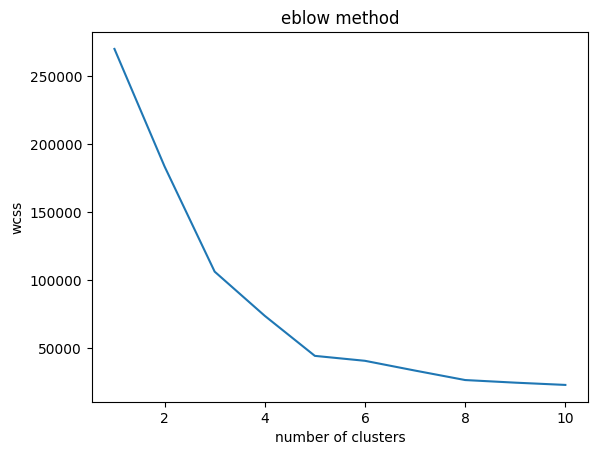

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


[4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4
 2 4 2 4 2 4 0 4 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 3 1 0 1 3 1 3 1 0 1 3 1 3 1 3 1 3 1 0 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1]


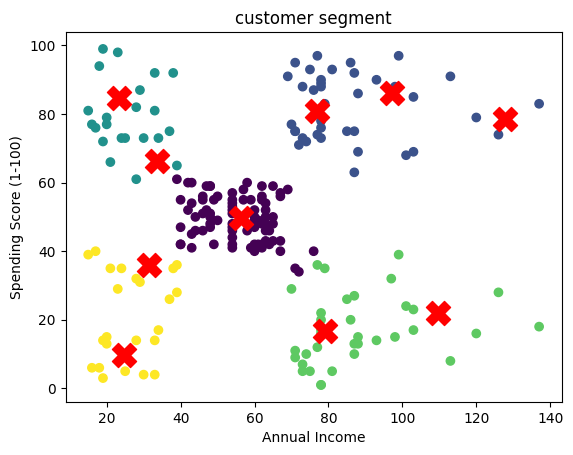

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# load dataset

data = pd.read_csv("Mall_Customers.csv")

x = data[['Annual Income (k$)','Spending Score (1-100)']]

# using elbow method find optional k 

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++',random_state = 42)
    kmeans.fit(x)
    wcss .append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title("eblow method")
plt.xlabel("number of clusters")
plt.ylabel("wcss")
plt.show()


# Apply k-mean clustering 

kmean = KMeans(n_clusters = 5, init = 'k-means++', random_state = 42)
pred = kmean.fit_predict(x)

print(pred)

# vasulization

plt.scatter(x.iloc[:,0], x.iloc[:,1], c = pred, cmap = 'viridis')
plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1], c = 'red', s = 300, marker = 'X')
plt.xlabel("Annual Income")
plt.ylabel("Spending Score (1-100)")
plt.title("customer segment")
plt.show()

In [ ]:
# Customer Product Segmentation (E-Commerce)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')


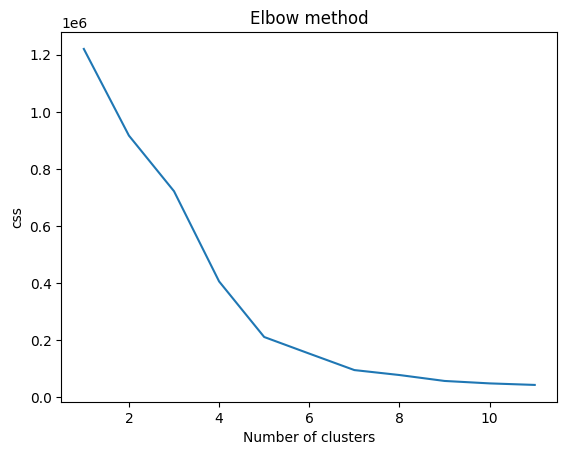

prediction: [5 5 5 ... 1 1 1]


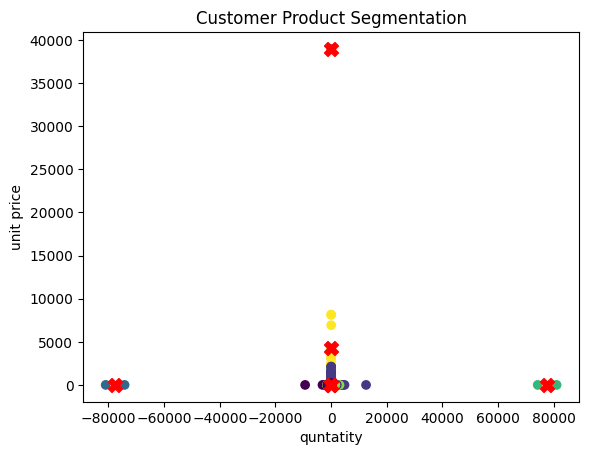

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# load dataset

data = pd.read_csv("OnlineRetail.csv",encoding="latin1")

print(data.columns)

x = data[['Quantity','UnitPrice','CustomerID']].dropna()

# standardscaler

scaler = StandardScaler()
x_scaler = scaler.fit_transform(x)

# finding k value of clustering 

css = []
for i in range (1, 12):
    kmeans = KMeans(n_clusters = i , init ='k-means++', random_state = 42)
    kmeans.fit(x_scaler)
    css.append(kmeans.inertia_)

plt.plot(range(1, 12), css)
plt.xlabel("Number of clusters")
plt.ylabel("css")
plt.title("Elbow method")
plt.show()


# fitting the model 

model = KMeans( n_clusters = 7, init = 'k-means++', random_state = 42)
pred = model.fit_predict(x_scaler)
print("prediction:",pred)

# vasulization
centers = scaler.inverse_transform(model.cluster_centers_)


plt.scatter(x.iloc[:,0],x.iloc[:,1], c = pred, cmap = 'viridis')
plt.scatter(centers[:,0],centers[:,1], c = 'red', s = 100 , marker = 'X')
plt.xlabel("quntatity")
plt.ylabel("unit price")
plt.title("Customer Product Segmentation")
plt.show()